In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
import cv2
from pathlib import Path

plt.rcParams['figure.figsize'] = (12,8)
plt.rcParams['axes.grid'] = True
sns.set_style('darkgrid')

ROOT = Path('../')
DATA_RAW = ROOT / 'data' / 'raw'

TRAIN_IMAGES = DATA_RAW / 'stage_2_train_images'
TEST_IMAGES = DATA_RAW / 'stage_2_test_images'
TRAIN_LABELS = DATA_RAW / 'stage_2_train_labels.csv'
CLASS_INFO = DATA_RAW / 'stage_2_detailed_class_info.csv'

### Data Structure

In [9]:
df_labels = pd.read_csv(TRAIN_LABELS)
df_class = pd.read_csv(CLASS_INFO)

print('Labels shape:', df_labels.shape)
print('Class info shape:', df_class.shape)
print()
print(df_labels.head(10))

Labels shape: (30227, 6)
Class info shape: (30227, 2)

                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1
5  00436515-870c-4b36-a041-de91049b9ab4  562.0  152.0  256.0   453.0       1
6  00569f44-917d-4c86-a842-81832af98c30    NaN    NaN    NaN     NaN       0
7  006cec2e-6ce2-4549-bffa-eadfcd1e9970    NaN    NaN    NaN     NaN       0
8  00704310-78a8-4b38-8475-49f4573b2dbb  323.0  577.0  160.0   104.0       1
9  00704310-78a8-4b38-8475-49f4573b2dbb  695.0  575.0  162.0   137.0       1


### Basic Statistics

In [10]:
print('Total rows:', len(df_labels))
print('Unique patients:', df_labels['patientId'].nunique())
print('Patient with pneumonia (Target = 1)', df_labels[df_labels['Target']==1]['patientId'].nunique())
print('Patients without pneumonia (Target = 0)', df_labels[df_labels['Target']==0]['patientId'].nunique())
print()
print('Rows per patient (min/max/mean):')
print(df_labels.groupby('patientId').size().describe())

Total rows: 30227
Unique patients: 26684
Patient with pneumonia (Target = 1) 6012
Patients without pneumonia (Target = 0) 20672

Rows per patient (min/max/mean):
count    26684.000000
mean         1.132776
std          0.356362
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
dtype: float64


unique patients: 26684

Class distribution
        count  percentage
Target                   
0       20672        77.5
1        6012        22.5


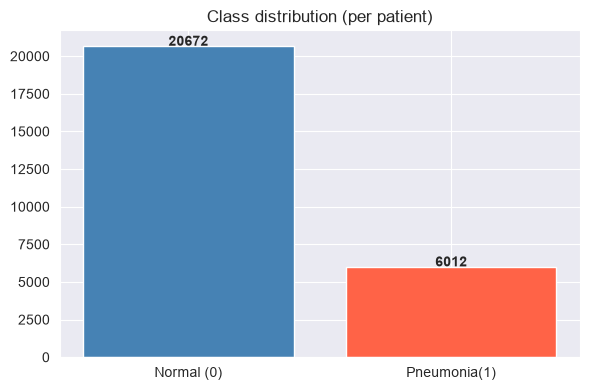

In [11]:
df_patients = df_labels.drop_duplicates(subset='patientId', keep='first').reset_index(drop=True)
print('unique patients:', len(df_patients))
print()

counts = df_patients['Target'].value_counts()
pct = df_patients['Target'].value_counts(normalize = True) * 100

print('Class distribution')
print(pd.DataFrame({'count' : counts, 'percentage': pct.round(1)}))

#plot
fig, ax = plt.subplots(1, 1, figsize = (6,4))
ax.bar(['Normal (0)', 'Pneumonia(1)'], counts.values, color = ['steelblue', 'tomato'])
ax.set_title('Class distribution (per patient)')
ax.set_label('count')

for i,v in enumerate(counts.values):
    ax.text(i, v+20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
df_boxes = df_labels[df_labels['Target'] == 1].copy()

print('Total bounding boxes:', len(df_boxes))
print('Patients with boxes:', df_boxes['patientId'].nunique())
print()
print('Boxes per patient:')
print(df_boxes.groupby('patientId').size().value_counts().sort_index())
print()
print('Box dimensions:')
print(df_boxes[['x', 'y', 'width', 'height']].describe().round(1))

Total bounding boxes: 9555
Patients with boxes: 6012

Boxes per patient:
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64

Box dimensions:
            x       y   width  height
count  9555.0  9555.0  9555.0  9555.0
mean    394.0   366.8   218.5   329.3
std     204.6   148.9    59.3   157.8
min       2.0     2.0    40.0    45.0
25%     207.0   249.0   177.0   203.0
50%     324.0   365.0   217.0   298.0
75%     594.0   478.5   259.0   438.0
max     835.0   881.0   528.0   942.0


In [13]:
def load_dicom(patient_id, image_dir):
    path = image_dir /f'{patient_id}.dcm'
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array
    img = (img - img.min()) / (img.max() - img.min()) * 255
    return img.astype(np.uint8)

def draw_boxes(img, boxes):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    for _, box in boxes.iterrows():
        x, y, w, h = int(box.x), int(box.y), int(box.width), int(box.height)
        cv2.rectangle(img_rgb, (x,y), (x+w, y+h), (255, 0, 0), 3)
    return img_rgb

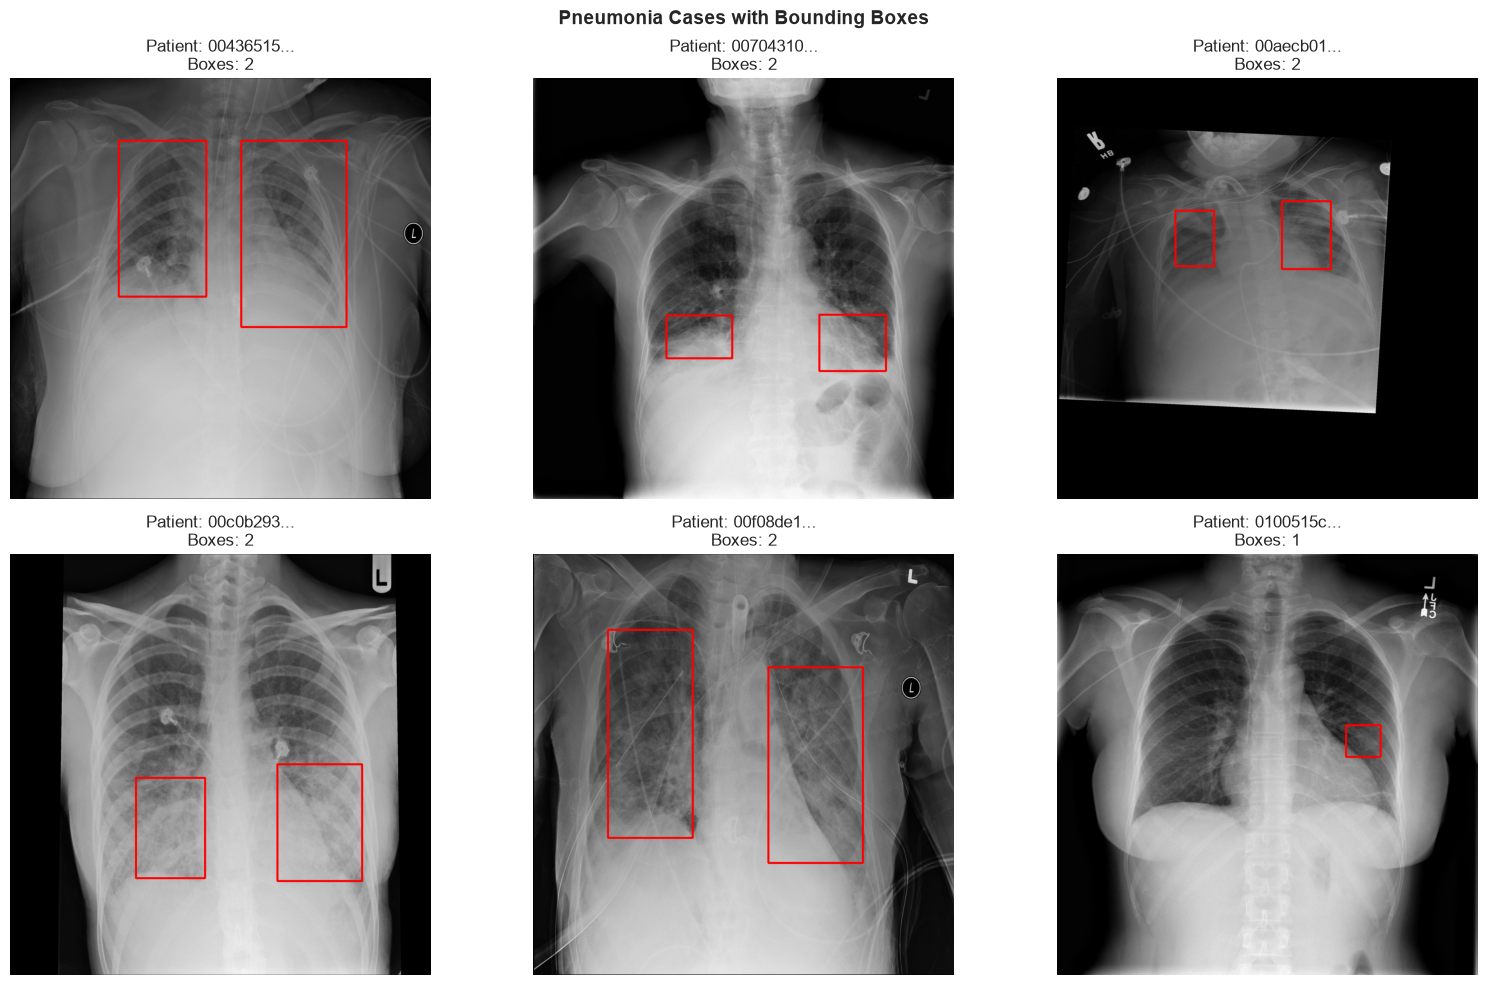

In [14]:
pneumonia_patients = df_labels[df_labels['Target']==1]['patientId'].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, pid in enumerate(pneumonia_patients):
    img = load_dicom(pid, TRAIN_IMAGES)
    boxes = df_labels[df_labels['patientId'] == pid]
    img_boxes = draw_boxes(img, boxes)
    axes[i].imshow(img_boxes)
    axes[i].set_title(f'Patient: {pid[:8]}...\nBoxes: {len(boxes)}')
    axes[i].axis('off')

plt.suptitle('Pneumonia Cases with Bounding Boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

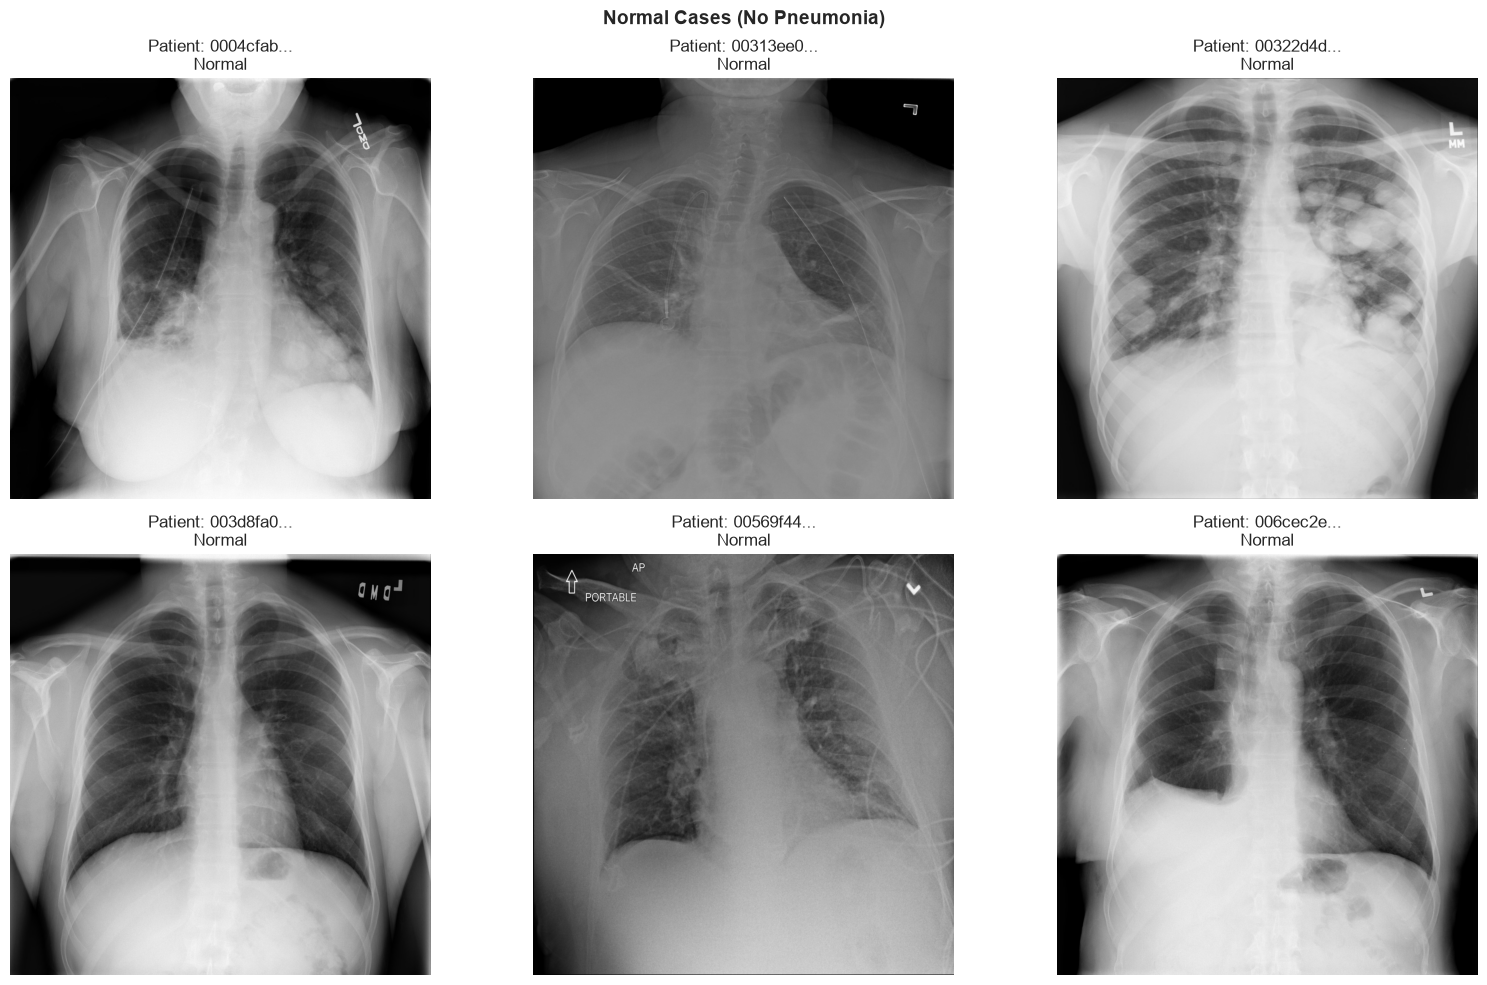

In [18]:
normal_patients = df_labels[df_labels['Target'] == 0]['patientId'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, pid in enumerate(normal_patients):
    img = load_dicom(pid, TRAIN_IMAGES)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'Patient: {pid[:8]}...\nNormal')
    axes[i].axis('off')

plt.suptitle('Normal Cases (No Pneumonia)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# checking a sample of images for size consistency
sample_pids = df_patients['patientId'].sample(20, random_state=42)
sizes=[]

for pid in sample_pids:
    dcm = pydicom.dcmread( TRAIN_IMAGES / f'{pid}.dcm')
    sizes.append({
        'patientId': pid,
        'rows': dcm.Rows,
        'cols': dcm.Columns,
        'bits': dcm.BitsStored
    })

df_sizes = pd.DataFrame(sizes)
print('Image size distribution')
print(df_sizes[['rows', 'cols', 'bits']].describe())
print()
print('Unique sizes:', df_sizes.groupby(['rows', 'cols']).size().reset_index(name='count'))

Image size distribution
         rows    cols  bits
count    20.0    20.0  20.0
mean   1024.0  1024.0   8.0
std       0.0     0.0   0.0
min    1024.0  1024.0   8.0
25%    1024.0  1024.0   8.0
50%    1024.0  1024.0   8.0
75%    1024.0  1024.0   8.0
max    1024.0  1024.0   8.0

Unique sizes:    rows  cols  count
0  1024  1024     20


Was checking the image size distribtion. As expected, all the images are the exact same size, but it was worth checking.

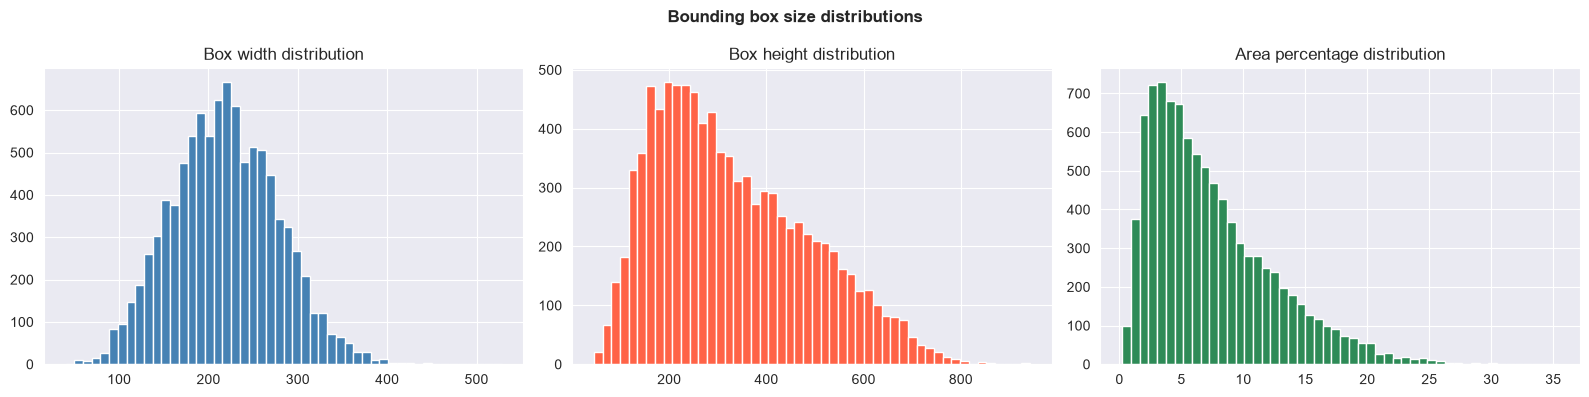

Median box covers 6.2% of the image
Mean box covers 7.4% of the image


In [22]:
df_boxes = df_labels[df_labels['Target']==1].copy()

#box area as fraction of image
df_boxes['area'] = df_boxes['width'] * df_boxes['height']
df_boxes['area_pct'] = df_boxes['area'] / (1024 * 1024) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_boxes['width'], bins = 50, color='steelblue', edgecolor='white')
axes[0].set_title('Box width distribution')
axes[0].set_label('Pixels')

axes[1].hist(df_boxes['height'], bins = 50, color='tomato', edgecolor='white')
axes[1].set_title('Box height distribution')
axes[1].set_label('Pixels')

axes[2].hist(df_boxes['area_pct'], bins = 50, color='seagreen', edgecolor='white')
axes[2].set_title('Area percentage distribution')
axes[2].set_label('Percentage')

plt.suptitle('Bounding box size distributions', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Median box covers {df_boxes['area_pct'].median():.1f}% of the image")
print(f"Mean box covers {df_boxes['area_pct'].mean():.1f}% of the image")